# System Performance Analysis

Includes latency, error rates, and user experience proxies.

## Setup

In [1]:
!uv sync --extra analysis

Resolved 219 packages in 1ms
Audited 181 packages in 24ms


In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from analysis.helpers import *

In [3]:
COMPA_RESULTS_DIR = Path("results/usability-ca")
# COMPB_RESULTS_DIR = Path("results/usability-cb")

## Run Overview / Metadata

#### Get runs data

In [4]:
print_metadata_summary(COMPA_RESULTS_DIR / "metadata.json")

Metadata Summary
----------------------------------------
Name: usability-ca
Link: http://127.0.0.1:8080
Runtime: 619.44s (10m 19s)

Complete run history
----------------------------------------
created/started: 2026-03-07 14:55:04.407582
started:        2026-03-07 14:55:04.413452
stopped:        2026-03-07 15:04:39.501869  (uptime 575.09s / 9m 35s)
destroyed:      2026-03-07 15:05:23.850363


In [5]:
runs_df = load_runs_ndjson(COMPA_RESULTS_DIR / "db/runs.ndjson")
print(list(runs_df.columns))

['name', 'source', 'start_ts', 'end_ts', 'output_fpaths', 'exited', 'saved', 'exit_reason', 'player_id', 'feedback', 'turns', 'runtime_seconds', 'runtime_string', '_id.$oid', 'game_config.name', 'game_config.description', 'game_config.version', 'game_config.authors', 'game_config.stopping_conditions.turns', 'game_config.access_settings.user.valid.players.where.consent_signature.answer.$exists', 'game_config.access_settings.new_player_form.preamble', 'game_config.access_settings.new_player_form.questions', 'game_config.data_collection_settings.save_runs', 'game_config.character_settings.pc.valid.characters.where.hid', 'game_config.character_settings.npc.valid.characters.where.hid.$ne', 'game_config.character_settings.npc.invalid.runs.where.player_id', 'game_config.character_settings.npc.invalid.runs.where.game_config.name', 'game_config.character_settings.npc.invalid.runs.where.context.npc.hid', 'game_config.character_settings.display_pc_choice_as', 'game_config.character_settings.displ

In [6]:
cols = {
    "player": "player_id",
    "game": "game_config.name",
    "pc": "context.pc.hid",
    "npc": "context.npc.hid",
    "turns": "turns",
    "duration_sec": "runtime_seconds",
    "exit_reason": "exit_reason",
    "state_exit_reason": "state.exit_reason",
    "retry_budget": "state.user_retry_budget",
    "start": "start_dt",
    "end": "end_dt",
}

view_df = runs_df[list(cols.values())].rename(columns={v: k for k, v in cols.items()})
view_df["pairing"] = view_df["pc"] + " → " + view_df["npc"]

display_pretty(view_df)

player,game,pc,npc,turns,duration_sec,exit_reason,state_exit_reason,retry_budget,start,end,pairing
69ac3c5eb1b0918d6e79515b,Infer Intent,human-normative,llm-gpt5,1,276,Game completed.,Game completed.,3,2026-03-07 14:57:37.310800+00:00,2026-03-07 15:02:14.232186+00:00,human-normative → llm-gpt5
69ac3c82b1b0918d6e79515c,Infer Intent,human-normative,human-non-hearing,3,326,Game completed.,Game completed.,3,2026-03-07 14:57:46.027414+00:00,2026-03-07 15:03:12.607040+00:00,human-normative → human-non-hearing
69ac3c9bb1b0918d6e79515d,Infer Intent,human-normative,algorithm-sort,1,356,received exit command,,2,2026-03-07 14:58:01.984267+00:00,2026-03-07 15:03:58.939614+00:00,human-normative → algorithm-sort


In [7]:
transcripts_df = get_transcripts_from_runs_df(runs_df)

In [8]:
display_pretty(transcripts_df)

run_id,player_id,pc,npc,turn,speaker,text,timestamp
69ac3df6b1b0918d6e79515e,69ac3c5eb1b0918d6e79515b,human-normative,llm-gpt5,1,ai,"You enter a new space. In this space, you sit at a small desk facing a single monitor whose chat-like window bears a pulsing cursor; the screen flickers and a line of typed text appears: 'System online. How can I assist you today?'",None
69ac3df6b1b0918d6e79515e,69ac3c5eb1b0918d6e79515b,human-normative,llm-gpt5,2,human,"I type ""whats your goal""?",None
69ac3df6b1b0918d6e79515e,69ac3c5eb1b0918d6e79515b,human-normative,llm-gpt5,3,ai,"The cursor blinks for a moment, then a new line of text types itself into the chat window: ""My goal is to assist you — to provide information, carry out tasks within this system, and help you achieve whatever you need. How would you like me to help right now?""",None
69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,1,ai,"You enter a new space. In this space, a sunlit corner of a small café with a long communal table and a chalkboard menu, a person sits across from an empty chair, fingers resting on a tablet. They look up, smile, raise one hand in a clear wave, and push the tablet toward you; the screen shows the typed word ""Hello"".",None
69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,2,human,"I say and gesture ""hello""",None
69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,3,ai,"They catch your gesture and their smile widens. They raise both hands and clearly sign ""HELLO"" in ASL, fingers moving deliberately, then hold the smile waiting for your next move.",None
69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,4,human,I say whats your goal?,None
69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,5,ai,"They watch your lips move but give no verbal response. After a brief tilt of the head, they sign clearly in ASL—fingers forming SORRY, then CAN YOU TYPE/ SIGN?—and push the tablet toward you. The tablet screen now reads: I can't hear. Please type or sign your question.",None
69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,6,human,"I say okay and type in the tablet ""whats your goal""?",None
69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,7,ai,"They read the tablet, nod once, then sign clearly in ASL—fingers spelling MY GOAL—before tapping the screen. The tablet displays the typed reply: ""My goal is to help make public spaces more accessible and to connect with others interested in inclusive design.""",None


### Get player data

In [9]:
players_df = load_players_ndjson(COMPA_RESULTS_DIR / "db/players.ndjson")
print(list(players_df.columns))

['_id', 'created_at', 'access_key_hash', 'access_key_prefix', 'access_key_revoked', 'full_name', 'email', 'phone_number', 'prior_experience', 'additional_comments', 'consent_to_followup', 'consent_signature', 'last_key_issued_at']


In [10]:
display_pretty(players_df)

_id,created_at,access_key_hash,access_key_prefix,access_key_revoked,full_name,email,phone_number,prior_experience,additional_comments,consent_to_followup,consent_signature,last_key_issued_at
000000000000000000000001,2026-01-01 00:00:00+00:00,ef260e9aa3c673af240d17a2660480361a8e081d1ffeca2a5ed0e3219fc18567,,False,None,None,None,Software developer with experience in AI systems,,[I consent to being contacted for a voluntary follow-up regarding this study.],"[I confirm that the information I have provided is true and accurate. I acknowledge that I have read and understand the research consent information above, and I agree to participate. I understand that checking this box constitutes my electronic signature.]",NaT
69ac3c5eb1b0918d6e79515b,2026-03-07 14:55:26.118000+00:00,d90fca15c9b2f15d70a44c39e5d422837d7ca417455bccb3dd69a79a2315c292,ak-glad-,False,None,None,None,,,[],"[I confirm that the information I have provided is true and accurate. I acknowledge that I have read and understand the research consent information above, and I agree to participate. I understand that checking this box constitutes my electronic signature.]",2026-03-07 14:55:26.119000+00:00
69ac3c82b1b0918d6e79515c,2026-03-07 14:56:02.745000+00:00,f91032992140c879ba03864c75ac2a8226440ac79b125ea9fddbd7221a2ef320,ak-manua,False,None,None,None,some training work,nopes,[I consent to being contacted for a voluntary follow-up regarding this study.],"[I confirm that the information I have provided is true and accurate. I acknowledge that I have read and understand the research consent information above, and I agree to participate. I understand that checking this box constitutes my electronic signature.]",2026-03-07 14:56:02.746000+00:00
69ac3c9bb1b0918d6e79515d,2026-03-07 14:56:27.038000+00:00,2729cff2cc92e83ef78c695d2feb30e8e0628536588fcf64c91d671a10174bc5,ak-vario,False,None,None,None,,,[I consent to being contacted for a voluntary follow-up regarding this study.],"[I confirm that the information I have provided is true and accurate. I acknowledge that I have read and understand the research consent information above, and I agree to participate. I understand that checking this box constitutes my electronic signature.]",2026-03-07 14:56:27.042000+00:00


### Get logs data

In [11]:
logs_df = load_logs(COMPA_RESULTS_DIR / "logs")
print(list(logs_df.columns))

['log_file', 'log_path', 'event_idx', 'parse_error', 'text', 'message', 'exception', 'extra', 'function', 'module', 'logger_name', 'line', 'file_name', 'file_path', 'level', 'level_no', 'level_icon', 'process_id', 'process_name', 'thread_id', 'thread_name', 'elapsed_seconds', 'elapsed_repr', 'time_repr', 'timestamp']


In [12]:
show(logs_df)

Loading ITables v2.7.0 from the internet... (need help?)


## Game/PC/NPC Pairing

Shows which combinations of PC/NPCs were played for which games

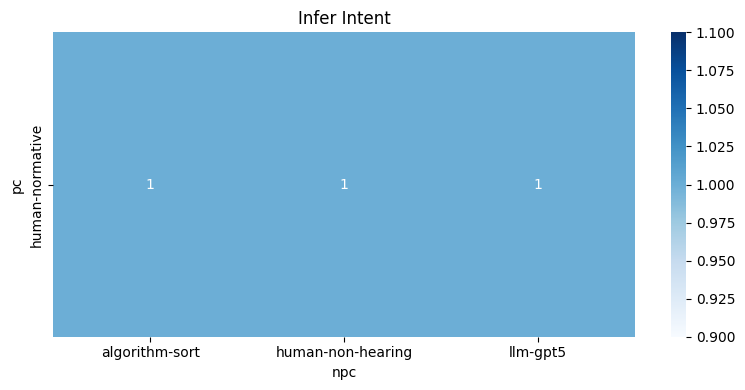

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

pair_counts = view_df.groupby(["game", "pc", "npc"]).size().reset_index(name="runs")

games = pair_counts["game"].unique()

fig, axes = plt.subplots(len(games), 1, figsize=(8, 4 * len(games)))

# ensure iterable
if len(games) == 1:
    axes = [axes]

for ax, game in zip(axes, games):
    pivot = pair_counts[pair_counts["game"] == game].pivot(index="pc", columns="npc", values="runs").fillna(0)

    sns.heatmap(pivot, annot=True, cmap="Blues", ax=ax)
    ax.set_title(game)

plt.tight_layout()

## Duration Distribution and Outliers

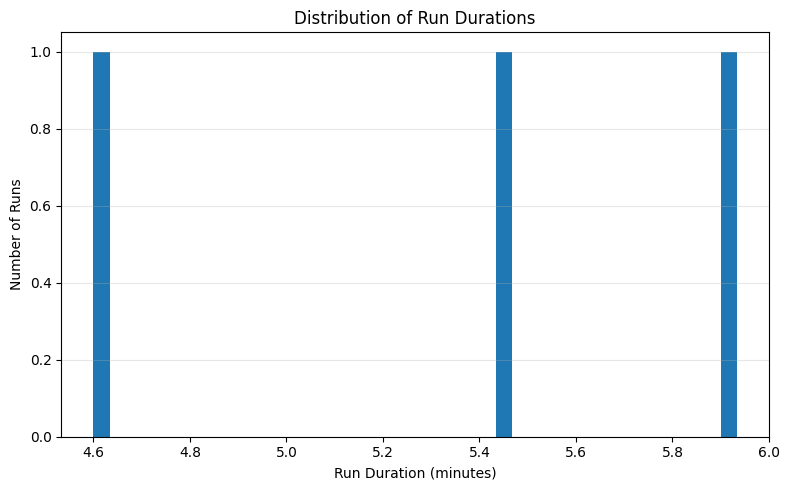

In [14]:
plt.figure(figsize=(8, 5))

(view_df["duration_sec"] / 60).plot.hist(bins=40)

plt.title("Distribution of Run Durations")
plt.xlabel("Run Duration (minutes)")
plt.ylabel("Number of Runs")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

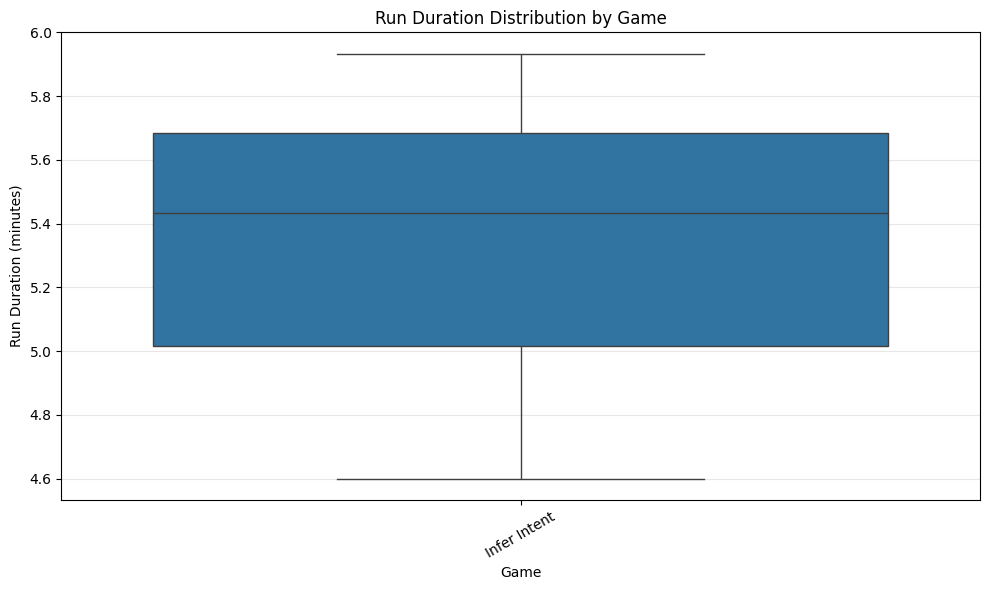

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=view_df, x="game", y=view_df["duration_sec"] / 60)

plt.title("Run Duration Distribution by Game")
plt.xlabel("Game")
plt.ylabel("Run Duration (minutes)")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Pacing (Turns vs. Duration)

Generally, more turns should take longer, if not it may be worth investigating.

Useful for spotting:
- stalled runs
- slow simulators
- games with many turns but short runtime

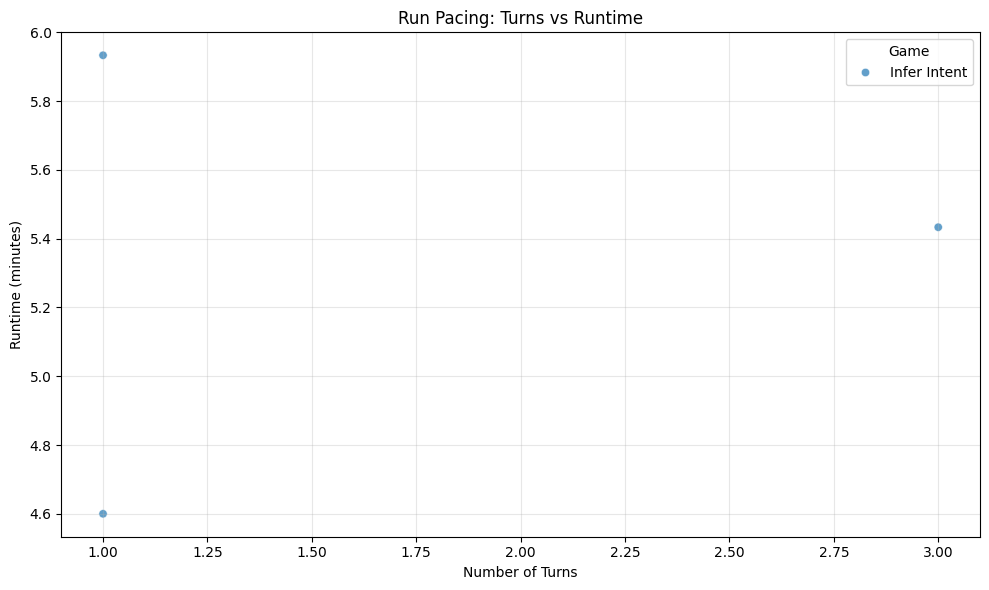

In [16]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=view_df, x="turns", y=view_df["duration_sec"] / 60, hue="game", alpha=0.7)

plt.title("Run Pacing: Turns vs Runtime")
plt.xlabel("Number of Turns")
plt.ylabel("Runtime (minutes)")

plt.grid(alpha=0.3)
plt.legend(title="Game")

plt.tight_layout()
plt.show()

## Exit Reasons

Useful for diagnosing early exits and incomplete runs.

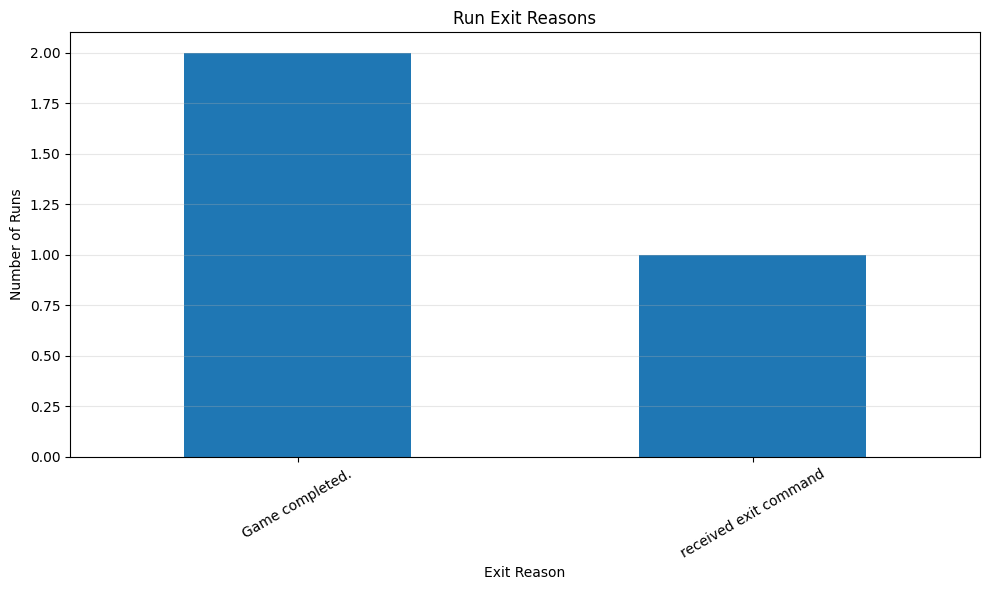

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

view_df["exit_reason"].value_counts().plot.bar()

plt.title("Run Exit Reasons")
plt.xlabel("Exit Reason")
plt.ylabel("Number of Runs")

plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Retry Budget Usage

Useful for spotting:
- if users made a lot of mistakes and needed to retry

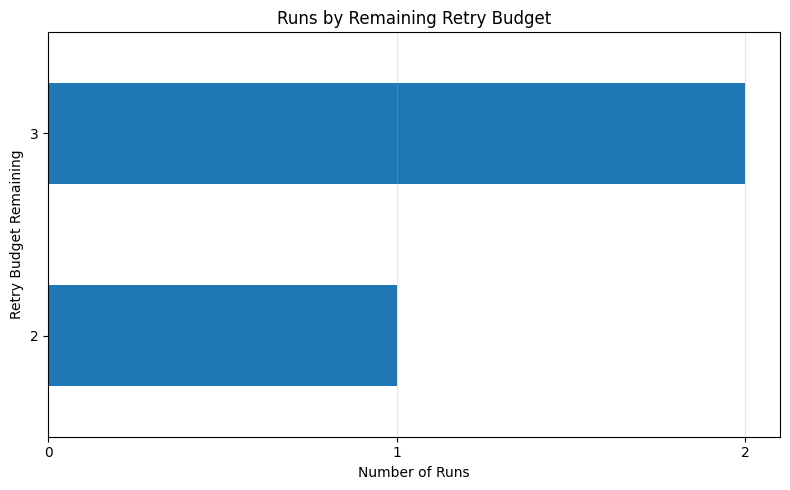

In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

retry_counts = view_df["retry_budget"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))

retry_counts.plot.barh(ax=ax)

ax.set_title("Runs by Remaining Retry Budget")
ax.set_xlabel("Number of Runs")
ax.set_ylabel("Retry Budget Remaining")

# force integer ticks
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Player Engagement

Useful for:
- engagement vs. fatigue across different participants demographics/classes

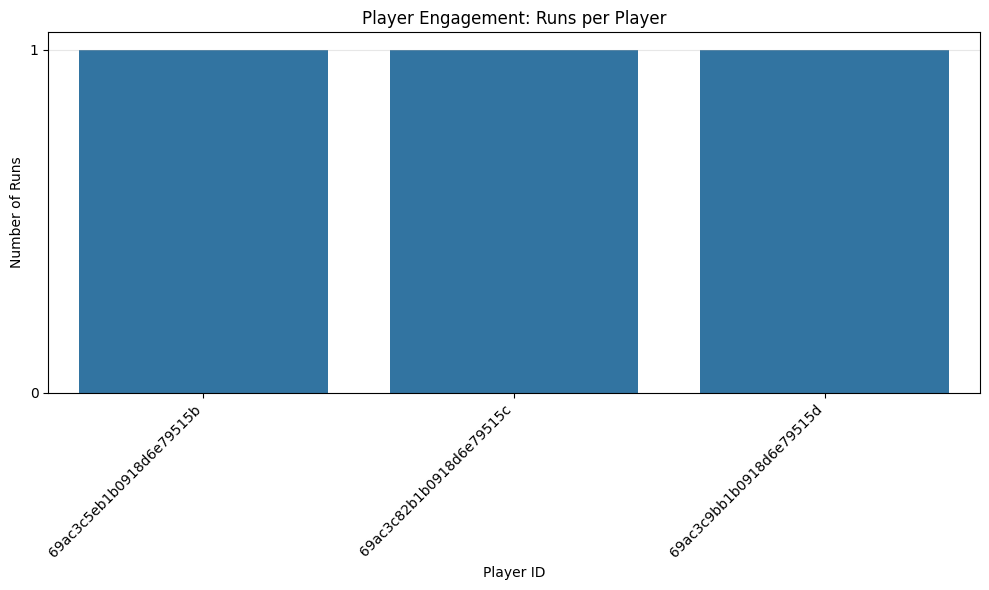

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

player_runs = view_df.groupby("player").size().reset_index(name="runs").sort_values("runs")

plt.figure(figsize=(10, 6))

ax = sns.barplot(data=player_runs, x="player", y="runs")

ax.set_title("Player Engagement: Runs per Player")
ax.set_xlabel("Player ID")
ax.set_ylabel("Number of Runs")

ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Number of runs by player data

In [20]:
runs_per_player = view_df.groupby("player").size().reset_index(name="runs").rename(columns={"player": "_id"})

engagement_df = players_df.merge(runs_per_player, on="_id", how="left")
engagement_df["runs"] = engagement_df["runs"].fillna(0)

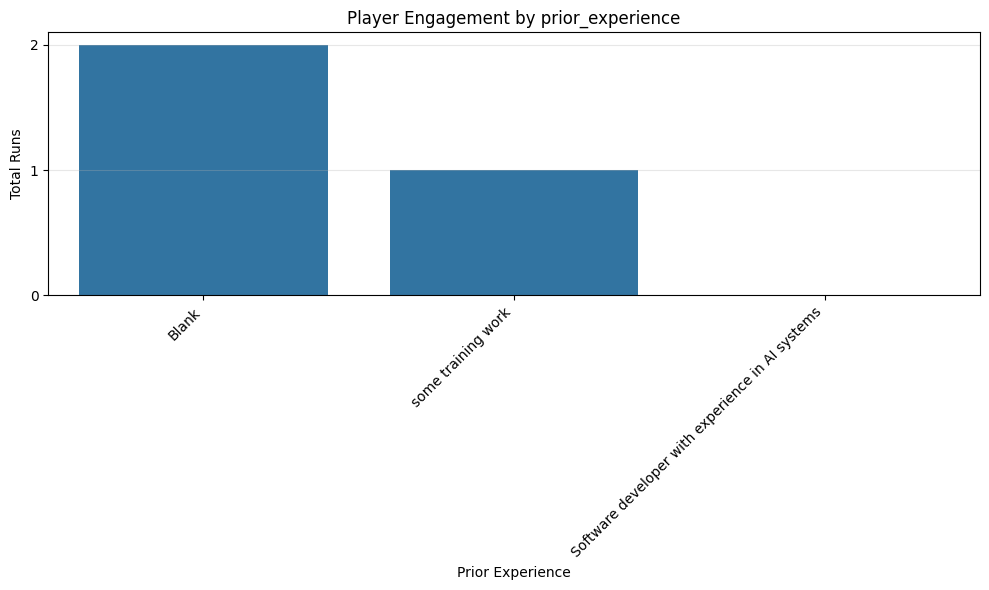

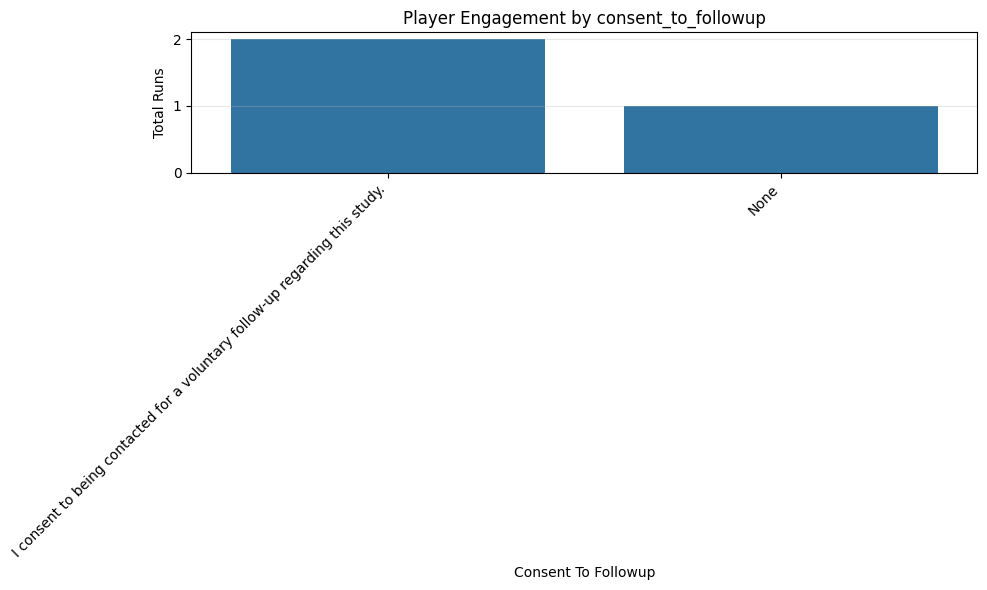

In [21]:
from helpers import plot_engagement_by

for col in ["prior_experience", "consent_to_followup"]:
    plot_engagement_by(engagement_df, col)

## Session Timeline

Plots runs over time to identify
- spikes

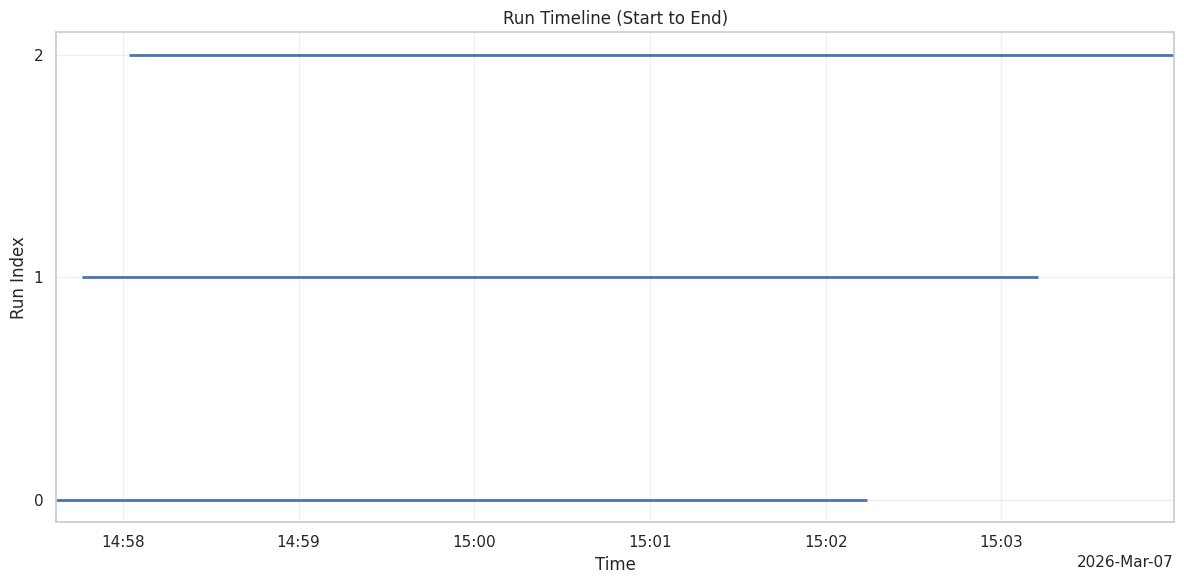

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

sns.set_theme(style="whitegrid")

timeline_df = view_df.dropna(subset=["start", "end"]).sort_values("start").reset_index(drop=True).copy()

timeline_df["run_idx"] = range(len(timeline_df))

fig, ax = plt.subplots(figsize=(12, max(6, len(timeline_df) * 0.15)))

for _, row in timeline_df.iterrows():
    ax.hlines(
        y=row["run_idx"],
        xmin=row["start"],
        xmax=row["end"],
        linewidth=2,
    )

ax.set_title("Run Timeline (Start to End)")
ax.set_xlabel("Time")
ax.set_ylabel("Run Index")

ax.set_xlim(timeline_df["start"].min(), timeline_df["end"].max())

# clean datetime ticks
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

# force integer run index ticks
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Latency

TODO: transcript data isn't timestamped currently, needs to be added so I can get this data

- What was simulator latency vs player latency per turn cycle? Comparable?
- How does latency change with players/turns/games?
- Whats per turn latency like for player, simulator? Are they comparable?
- Simulator latency over time, is it stable? By game? By player?

In [23]:
transcripts_df

,run_id,player_id,pc,npc,turn,speaker,text,timestamp
0,69ac3df6b1b0918d6e79515e,69ac3c5eb1b0918d6e79515b,human-normative,llm-gpt5,1,ai,"You enter a new space. In this space, you sit ...",None
1,69ac3df6b1b0918d6e79515e,69ac3c5eb1b0918d6e79515b,human-normative,llm-gpt5,2,human,"I type ""whats your goal""?",None
2,69ac3df6b1b0918d6e79515e,69ac3c5eb1b0918d6e79515b,human-normative,llm-gpt5,3,ai,"The cursor blinks for a moment, then a new lin...",None
3,69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,1,ai,"You enter a new space. In this space, a sunlit...",None
4,69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,2,human,"I say and gesture ""hello""",None
5,69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,3,ai,They catch your gesture and their smile widens...,None
6,69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,4,human,I say whats your goal?,None
7,69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,5,ai,They watch your lips move but give no verbal r...,None
8,69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,6,human,"I say okay and type in the tablet ""whats your ...",None
9,69ac3e30b1b0918d6e79515f,69ac3c82b1b0918d6e79515c,human-normative,human-non-hearing,7,ai,"They read the tablet, nod once, then sign clea...",None


## System Errors

- How many warning, errors, etc in logs?

In [24]:
# Show warnings / errors / criticals / exceptions in a clean table

problem_levels = {"WARNING", "ERROR", "CRITICAL"}

problems_df = (
    logs_df[
        logs_df["level"].isin(problem_levels)
        | logs_df["exception"].notna()
        | logs_df["message"].str.contains(
            r"error|exception|traceback|failed|failure|warning|critical",
            case=False,
            na=False,
            regex=True,
        )
    ]
    .sort_values(["timestamp", "log_file", "event_idx"])
    .reset_index(drop=True)
)

cols = [
    "timestamp",
    "log_file",
    "event_idx",
    "level",
    "file_name",
    "line",
    "function",
    "message",
    "exception",
]

In [25]:
show(problems_df[cols])

Loading ITables v2.7.0 from the internet... (need help?)


## Extraneous User Actions

TODO: not currently collected in run data transcripts!

- How many times did users make invalid actions or use help menus? Any invalid actions back to back?
- How many users get invalid or error messages? Any more than once?
- Ho many times did users use commands (/bla) for their turns?